# RAG System For Intelligent Robotics Course

<div align="center">

**Authors**

*Chinello Alessandro* *{Computer Engineering} {2157196}*

*Piai Luca* *{Computer Engineering} {2157195}*

</div>


## Importing modules and Dowload Dataset

In this section we setup all the modules and the data needed to create the dataset for the rag.

In [ ]:
# Dowload all needed modules.
!pip install transformers sentence-transformers faiss-cpu hf_transfer pandas matplotlib seaborn mdclense openai bert-score accelerate

In [ ]:
# Import all necessary modules.
import json
import os
from mdclense.parser import MarkdownParser
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import time
from openai import OpenAI
from bert_score import score as bscore
import random

# Needed for faster dowloads (not sure).
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [ ]:
# Define global variables.

# Directory where the markdown chapters will be dowloaded.
RAW_DATA_DIR = "./data/raw_data/"
# Json file where chunks are stored.
KB_JSON = "./data/kb_docs.json"

# Model used for embed the sentences (docs and queries).
SENTENCE_EMBEDDING_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
# Model used to generate answers to our queries.
GENERATOR_MODEL_ID = "Qwen/Qwen3-8B"

# Json output where you can find all the queries, the associated
# answers (gold answer + rag answer) and the grades + comments given by deepseek.
FINAL_OUTPUT_JSON = "./final_output.json"

# Deepseek api (used to compare gold answers vs. rag answers)
DEEPSEEK_API = "YOUR API KEY"

In [ ]:
# Here we download all the necessary files from our git repository.

# Download the chapters and store them into 'data' folder.
!curl -s https://api.github.com/repos/Ultimi-Sumiti/RAG-system/contents/data/raw_data/chapters \
| grep "download_url" \
| cut -d '"' -f 4 \
| xargs -n 1 curl -L -O --create-dirs --output-dir data/raw_data

# Dowload quesions and answers.
!curl -L -O https://raw.githubusercontent.com/Ultimi-Sumiti/RAG-system/main/data/questions_answers.json --output-dir data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5184  100  5184    0     0  84850      0 --:--:-- --:--:-- --:--:-- 83612
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4133  100  4133    0     0  67169      0 --:--:-- --:--:-- --:--:-- 67754
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8822  100  8822    0     0   142k      0 --:--:-- --:--:-- --:--:--  143k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1708  100  1708    0     0  28221      0 --:--:-- --:--:-- --:--:-- 28466
  % Total    % Received % Xferd  Average Speed   Tim

In [1]:
# Uncomment the following lines if you want to store the
# llm model (that we will use later) into your personal gdrive.
# NOTE that the first time you dowload the model, it will take some time.

cache_dir = None
from google.colab import drive
drive.mount('/content/drive')
# Create a cache folder in your Drive.
cache_dir = "/content/drive/MyDrive/hf_model_cache"
os.makedirs(cache_dir, exist_ok=True)
# Set hugging face cache dir.
os.environ["HF_HOME"] = cache_dir

Mounted at /content/drive


NameError: name 'os' is not defined

## Preprocessing: creating the knowledge base

Our dataset is composed by 10 markdown files, each file contains a single chapter.
Those file are notes from the course of Intelligent Robotics (a course from UNIPD).

The chapters:
1. `intro_to_robotics.md`
2. `locomotion.md`
3. `kin_mobile_robots.md`
4. `robot_perception.md`
5. `local_and_mapping.md`
6. `motion_planning.md`
7. `motion_planning_paper.md`
8. `architectures_paradigm.md`
9. `human_robot_interaction.md`
10. `sensor_paper.md`


In this section we perform the following operations:

1. For each chapter: remove markdown tags.
2. Merge all chapters into a single document file (`./data/cleaned_raw_text.txt`)
3. Split the raw document into smaller chunks:
    - Chunk size = 150 words
    - Overlapping percentage = 10%
4. Store chunks into a json file (`./data/kb_docs.json`).

In [ ]:
def create_overlapping_chunks(word_list, chunk_size, overlap_pct):
    """ Given a list of strings it returns a list of ovelapping chunks """
    # Calculate the number of overlapping words.
    overlap_count = int(chunk_size * overlap_pct)
    # Create the chunks.
    step = chunk_size - overlap_count
    chunks = [
        word_list[i : i + chunk_size]
        for i in range(0, len(word_list), step)
    ]
    output = ["".join(x + " " for x in ls) for ls in chunks]
    return output

In [ ]:
# Create a list containing the text of each chapter file.
ls = []
for file in os.listdir(RAW_DATA_DIR):
    # File path.
    fp = os.path.join(RAW_DATA_DIR, file)
    # Open file and append content to list.
    with open(fp, 'r') as f:
        t = f.read()
        ls.append(t)

# Merge the content of each chapter into a single string.
text = "".join([x for x in ls])
print("Document lenght (chars):", len(text))

Document lenght (chars): 65374


In [ ]:
# Remove markdown tags from the text.
parser = MarkdownParser()
clean = parser.parse(text)
print("Cleaned document length (chars):", len(clean))
ls_clean = clean.split()
print("Number of words in the document:", len(ls_clean))
# Store cleaned text to disk.
with open("./data/cleaned_raw_text.txt", 'w') as f:
    f.write(clean)

Cleaned document length (chars): 58805
Number of words in the document: 8525


In [ ]:
# Create the chunks.
chunk_size = 150
overlap_pct = 0.1

# Get list of chunks.
ls_docs = create_overlapping_chunks(ls_clean, chunk_size=chunk_size, overlap_pct=overlap_pct)
# Print some stats.
non_overlap = len(ls_clean) // chunk_size
print("Total blocks (non overlapping):", non_overlap)
print("Total blocks (overlapping)", len(ls_docs))

# Store chunks into a json file.
kb = [{"id":i, "text": text} for i, text in enumerate(ls_docs)]
with open(KB_JSON, 'w') as f:
    json.dump(kb, f, indent=4)

Total blocks (non overlapping): 56
Total blocks (overlapping) 64


## Dataset Profiling

In this section we plot some statistics about the our documents.

To encode the chunks/passages, we've decided to use `all-MiniLM-L6-v` model. From the documentation, the intended uses:

> *Our model is intended to be used as a sentence and short paragraph encoder. Given an input text, it outputs a vector which captures the semantic information. The sentence vector may be used for information retrieval, clustering or sentence similarity tasks.*

This is perfect for our simple application.

In [ ]:
# Define raw data input and tokenizer.
file_path = './data/cleaned_raw_text.txt'
tokenizer = AutoTokenizer.from_pretrained(SENTENCE_EMBEDDING_MODEL_ID)
with open(file_path, 'r') as f:
    raw_text = f.read()

In [ ]:
# Some basic stats on raw dataset.
char_count = len(raw_text)
words = raw_text.split()
word_count = len(words)
tokens = tokenizer.encode(raw_text, add_special_tokens=False)
total_tokens = len(tokens)
unique_tokens = len(set(tokens))
print(f"### Raw Dataset Stats ###")
print(f"Total Characters: {char_count}")
print(f"Total Words:      {word_count}")
print(f"Total Tokens:     {total_tokens}")
print(f"Vocabulary Size:  {unique_tokens}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (12706 > 512). Running this sequence through the model will result in indexing errors


### Raw Dataset Stats ###
Total Characters: 58805
Total Words:      8525
Total Tokens:     12706
Vocabulary Size:  2430



### Chunking Stats ###
Number of chunks: 64


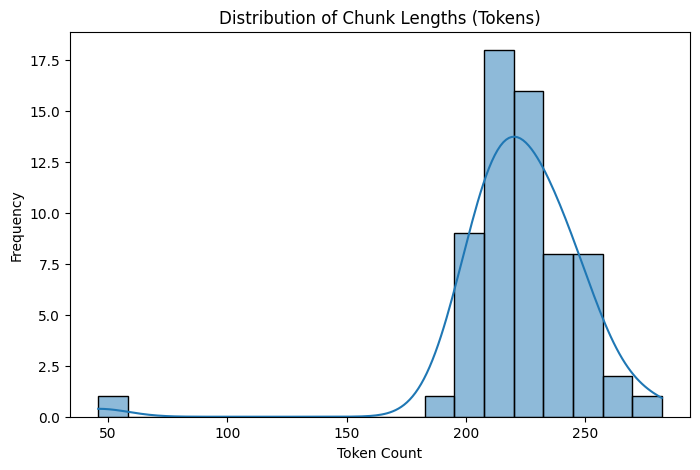

In [ ]:
# Chunks stats.
with open(KB_JSON, 'r') as f:
    chunks = json.load(f)

chunk_lengths = [len(tokenizer.encode(c["text"])) for c in chunks]
df_chunks = pd.DataFrame(chunk_lengths, columns=['token_length'])
print(f"\n### Chunking Stats ###")
print(f"Number of chunks: {len(chunks)}")

plt.figure(figsize=(8, 5))
sns.histplot(df_chunks['token_length'], kde=True)
plt.title('Distribution of Chunk Lengths (Tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.show()
plt.close()

The last chunk contains fewer tokens than the others.
Apart from this final chunk, all remaining chunks are nicely distributed.

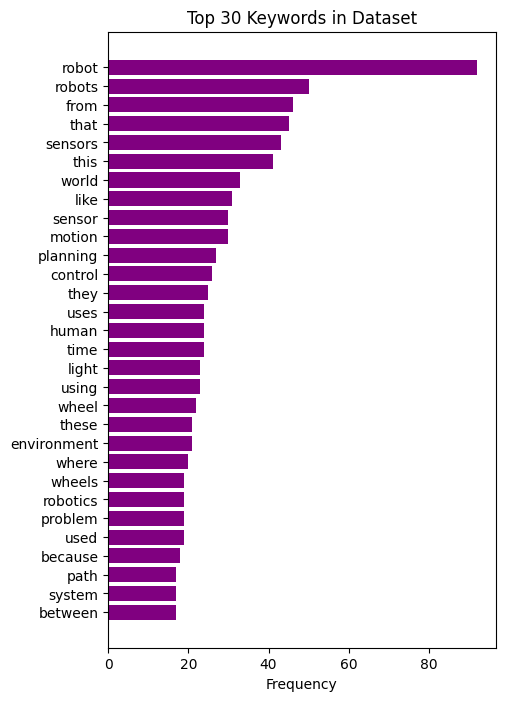

In [ ]:
# Simple cleanup for keyword frequency.
clean_text = re.sub(r'[^\w\s]', '', raw_text.lower())
stop_words = {'the', 'and', 'to', 'of', 'a', 'in', 'is', 'it', 'for', 'on', 'with', 'as'}
filtered_words = [w for w in clean_text.split() if w not in stop_words and len(w) > 3]
word_counts = Counter(filtered_words)

# Display table.
df_freq = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency'])
df_freq = df_freq.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
#print("### Top 30 Keywords in Dataset ###")
#print(df_freq.head(30))

# Print figure.
plt.figure(figsize=(5, 8))
plt.barh(df_freq.head(30)['Word'], df_freq.head(30)['Frequency'], color='purple')
plt.title('Top 30 Keywords in Dataset')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()
plt.close()

We can see that many words are related to *robotics* domain. For example: `robot`, `sensor`, `motion`, `planning`, etc.

## Generate answers

**About the generation process.** We decided to test our model on 50 queries. We've created 5 question for each chapter stored in `./data/raw_data/` folder. Each question is paired with a golden answer. The queries and answers are stored in `./data/questions_answers.json`.

**How did we get the queries/answers?**  The queries were generated by [NotebookLM](https://notebooklm.google/): we gave as input the chapters in `./data/raw_data/` and we asked to provide 5 questions for each one. After that we've asked it to generate the (gold) answers. If you're interested, [here](https://notebooklm.google.com/notebook/a13aa671-ee76-47e7-9680-c6108f0349f1/preview) you can find the chat we had with NotebookLM.

**Generation process steps.**

- Read knowledge base and encode all documents.
- Create the vector database with the documents embeddings.
- Load the model (Qwen3-8B) and retreive all queries (from disk).
- Encode all the queries $q$ and search the top-k document similar to the query embedding.
- Create a prompt for each query and store the result given by the model.
- Finally we store the rag answers to disk (`./final_output.json`).

### Sentence embeddings

In [ ]:
# Encode our knowledge base using a model for sentence embedding.

# Open our .json file with all the chunks and save it into a list of dictionaries
with open(KB_JSON, 'r') as f:
    chunks = json.load(f)
print("Number of chunks", len(chunks))

print("Some Chunks: ")
for i,a in enumerate(chunks):
  if i < 5:
    print(a)
  else:
    break

# Create a list containing all the strings inside the 'text' folder for each chunk
TEXT_CHUNKS = [c['text'] for c in chunks]

# Set our encoder model and encode the list of strings of the chunk
encoder = SentenceTransformer(SENTENCE_EMBEDDING_MODEL_ID)
chunks_embd = encoder.encode(TEXT_CHUNKS)
# Print the dimension of our encoded vectors, we expect a 2D numpy array of shape (64, 384) by structural properties of all-MiniLM-L6-v2
print(chunks_embd.shape)

Number of chunks 64
Some Chunks: 
{'id': 0, 'text': "Sensor Technologies in Mobile Robotics (Paper 1) Definition and Classification Sensor vs. Transducer: A transducer is a device that converts one form of energy into another (e.g., mechanical to electrical). A sensor is a receiver transducer that measures a physical parameter (like light or sound) and converts it into a signal. An actuator is an emitter transducer that injects energy into the environment. Excitation Source: Passive Sensors: Do not require an external power supply to generate an excitation signal; they only receive energy already present (e.g., a camera receiving light, a microphone). Active Sensors: Require power to generate their own excitation signal and measure the reaction (e.g., Sonar or LiDAR emitting pulses). Measurement Domain: Proprioceptive: Measure internal robot states (e.g., battery level, wheel speed via encoders). Exteroceptive: Measure the environment and the robot's interaction with it (e.g., distance

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(64, 384)


### Build the retreiver

In [ ]:
# Use Faiss to build the Retriver, that is obtaining the top k
# index of chuncks for the relative query.

# Dimension  384
d = chunks_embd.shape[1]

# Build the index object, it encapsulates the set of database vectors,
# it requires the size of chuncks that it needs to process.
index = faiss.IndexFlatL2(d)
print(index.is_trained)
# Add vectors embeddings of the chunks to the index
index.add(chunks_embd)

# We want to see top-k nearest neighbors (top-k docs to retrive)
# related to a specific query.
k = 3

# Read the Q&A .json file and store into a list
Q_A_JSON = "./data/questions_answers.json"
with open(Q_A_JSON, 'r') as f:
    q_a_docs = json.load(f)

# Save in lists queries and answers generated by NotebookLM
QUERIES = [c['question'] for c in q_a_docs]
GOLD_ANSWERS = [c['answer'] for c in q_a_docs]

# Embedded also the queries thanks to our encoder model
queries_embd = encoder.encode(QUERIES)
#print(queries_embd)
print("Shape of embedded queries: ",queries_embd.shape)

# D is the distance , I is the index of the vector emmbedding
# Exploit index object to make the search of the top-k chuncks (which represent the top k-docs) to retrive
# In practice inside the I matrix we have store the mapping necessary to link a query q with its top-k neighboors (aka the retrived chunks)
D, I = index.search(queries_embd, k)

# Top 3 chunk for the first 5 queries (out of 50)
print("Top 3 chunks for first 5 queries \n", I[:5])

True
Shape of embedded queries:  (50, 384)
Top 3 chunks for first 5 queries 
 [[17 18 20]
 [48 18 17]
 [19 21 20]
 [20 48 21]
 [21 20 19]]


In [ ]:
# Print some information to see the structure of I and D matrices and the mapping with top k chunks (retrived documents)
print("First row of I: ", I[0], '\n')


print("First top-k chunk for first query: ", chunks[I[0][0]],'\n')
print("Second top-k chunk for first query: ", chunks[I[0][1]],'\n')
print("Third top-k chunk for first query: ",chunks[I[0][2]],'\n')

print("Distance bewtween first top-k chunck and first query: ", D[0][0],'\n')
print("Distance bewtween second top-k chunck and first query:", D[0][1],'\n')
print("Distance bewtween third top-k chunck and first query:", D[0][2],'\n')


First row of I:  [17 18 20] 

First top-k chunk for first query:  {'id': 17, 'text': 'visited location, it adds a "Loop Closure" constraint, which drastically reduces accumulated drift and corrects the entire map. Software Architectures for robotics and robotics paradigms Robot Architectures The Hierarchical Paradigm (Classic AI) The Cycle: This paradigm, dominant from the late 60s to the 80s, operates on a strict serial sequence: SENSE $\\rightarrow$ PLAN $\\rightarrow$ ACT. Characteristics: It focuses heavily on "planning." The robot perceives the world to update an internal global model, reasons upon that model to generate a plan, and then executes it. Examples: Shakey (1967): The first AI robot, developed by SRI. It used the STRIPS algorithm to plan actions based on a logical description of the world (predicates like INROOM or PUSHABLE). The Monkey and Banana Problem: A classic test case where a planner must deduce how to move a box to reach a banana. It highlights the reliance on 

### Create prompts and feed the model

In [ ]:
# Load the tokenizer of the model.
tokenizer_qwen = AutoTokenizer.from_pretrained(GENERATOR_MODEL_ID, cache_dir=cache_dir)

# Load generator model.
model_qwen = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_ID,
    torch_dtype="auto",
    device_map="auto",
    cache_dir=cache_dir
)

model.safetensors.index.json:   0%|          | 0.00/32.9k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
system_context = """You are a helpful assistant.
Use the retrieved documents to answer the question as best as you can.
If you don't know the answer, say you don't know.
Your answer are short and concise"""

# Here we store the answers given by the rag.
RESULTS = []

# For each query build the prompt and send it to the model
for i, (query,idx) in enumerate(zip(QUERIES,I)):
    print(f"### Query number {i} ###\nQuery: {query}")

    # Save the specific top k document retrived before for that specific query
    TOP_CHUNKS = [TEXT_CHUNKS[i] for i in idx]

    # Building the prompt for a speicific query : top_chunks (retrived information) + query
    user_prompt = f"Here is some useful context: {'\n'.join(TOP_CHUNKS)}\nHere is the query: {query}"

    # Build our input following the rules of the library hugging face
    # We pass not just a block of text but a structured 'conversation'
    messages = [
        {"role": "system", "content": system_context}, # Context
        {"role": "user", "content": user_prompt} # Prompt question + retrived informations
    ]

    # Tokenization with Qwen of our prompt passing the messages
    inputs = tokenizer_qwen.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=False # Because qwen is a reasoning model and uses a lot of RAM
    ).to(model_qwen.device)

    # Send the prompt to Qwen
    outputs = model_qwen.generate(**inputs, max_new_tokens=300)
    # Decoding with the tokenizer to obtain the real "readable" output
    answer = tokenizer_qwen.decode(outputs[0][inputs["input_ids"].shape[-1]:])

    # Build the list with the final results
    RESULTS.append(answer)
    print(f"Answer: {answer}")


### Query number 0 ###
Query: Why did the classic Hierarchical Paradigm (Sense-Plan-Act) ultimately fail to handle real-world robotic applications effectively, especially regarding the 'Closed World Assumption'?
Answer: The classic Hierarchical Paradigm (Sense-Plan-Act) ultimately failed to handle real-world robotic applications effectively because of the **Closed World Assumption**, which assumes the internal model is perfect and contains all relevant information. This approach cannot handle new, undefined objects or dynamic changes in the environment, making it unsuitable for real-world scenarios where the world is constantly changing and unpredictable.<|im_end|>
### Query number 1 ###
Query: How does the concept of 'emergent behavior' in the Reactive Paradigm challenge the traditional AI notion that robots require complex internal reasoning to perform sophisticated tasks?
Answer: The concept of 'emergent behavior' in the Reactive Paradigm challenges the traditional AI notion by show

In [ ]:
# Save the RESULTS in a .json file
res_dic = q_a_docs
for res, dic in zip(RESULTS, res_dic):
    dic["ragAnswer"] = res

with open(FINAL_OUTPUT_JSON, 'w') as f:
    json.dump(res_dic, f, indent=4)

print(f"RAG answers saved to {FINAL_OUTPUT_JSON}")

RAG answers saved to ./final_output.json


## Evaluate the answers

In this section we evalute the answers given by the RAG by comparing them with the gold answers.
The evaluation is performed in three different ways.

**Deepseek evaluation.** We've asked Deepseek v4 flash (with *thinking* enabled) to act as a judge.
Deepseek receives as input a **teacher answer** (aka the gold answer) and the corresponding **student answer** (aka the answer of our rag model), its job is to grade the student answer with a value between 0 and 5. Also we've asked Deepseek to add a short comment, just to understand the meaning of the given grade. In the evaluation process, deepseek must consider both meaning of the two sentences and also it must check if all keywords in the teacher answer are also present in the student answer.

**Cosine similarity between answers.** We've used a sentence transformer (again `all-MiniLM-L6-v`) to embed both the gold answers and the answers given by the RAG and we've computed the cosine similarity between each pair.

**BERTScore.** Last evaluation is performed by means of BERTScore (using the module `bert_score`).

In [ ]:
# Open output json file with golden answers and rag answers.
with open(FINAL_OUTPUT_JSON, 'r') as f:
    data = json.load(f)

# Define the list of answers.
golden_answers = [dic['answer'] for dic in data]
rag_answers = [dic['ragAnswer'] for dic in data]

### Deepseek v4 flash as a judge

In [ ]:
# Init Deepseek client.
client = OpenAI(
    api_key=DEEPSEEK_API,
    base_url="https://api.deepseek.com"
)

# Function used to generate an answer from deepseek.
def generate_answer_ds(client, messages):
    response = client.chat.completions.create(
        model="deepseek-v4-flash",
        messages=messages,
        stream=False,
        extra_body={"thinking": {"type": "enabled"}}
    )
    return response.choices[0].message.content

In [ ]:
system_prompt =  """You have the following task: given two answers you need to evaluate
the similarity (in terms of meaning) between the two. The first answer is the
'teacher answer', the second one is the 'student answer'.
You have to evaluate the student answer by returing a single value between
0 and 5, where 0 means that the student gave a completely wrong answer;
5 means that the student answer has the same keywords mentioned in the teacher answer
and the overall meaning is the same.
Reply with the grade and a very brief comment. The output format must be: <your grade>, <your comment>.
Don't add anything else."""

# Small test: the score should be 0.
user_message = f"""Here is the teacher answer: {golden_answers[12]}\nHere is the student answer: {rag_answers[8]}"""
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_message}
]
out = generate_answer_ds(client, messages)
print("Score shuold be 0! Output:", out)

# List where we store the scores.
scores = []

cnt = 0
for gold_ans, rag_ans in zip(golden_answers, rag_answers):
    # Create messages.
    user_message = f"""Here is teacher answer: {gold_ans}\n\n Here is student answer: {rag_ans}"""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message}
    ]

    # Get ouput, store score.
    out = generate_answer_ds(client, messages)
    scores.append(out)

    print(f"Pair: {cnt}, output: {out}")
    cnt += 1

Score shuold be 0! Output: 0, The student answer discusses a different topic (Shared Intelligence for BMIs) unrelated to cobots and their safety features.
Pair: 0, output: 4, Good alignment on Closed World Assumption and handling unknowns, but missing the Frame Problem and speed issues.
Pair: 1, output: 5, Both convey the same core idea.
Pair: 2, output: 5, Correct and adds relevant detail.
Pair: 3, output: 5, The student answer captures the same meaning and keywords, with minor phrasing differences.
Pair: 4, output: 5, Nearly identical meaning; student elaborates with consistent details.
Pair: 5, output: 5, Student answer captures the same concept and adds relevant example.
Pair: 6, output: 5, The student answer captures the same key concepts and meaning as the teacher answer, with slightly more elaboration.
Pair: 7, output: 5, Perfect alignment in meaning and key points.
Pair: 8, output: 5, The student answer captures the same core idea: noisy/probabilistic BMI commands require combi

In [ ]:
# Store scores to disk.
scores_dict = data
for score, dic in zip(scores, scores_dict):
    dic['score'] = int(score[0])
    dic['comment'] = score[3:]
with open(FINAL_OUTPUT_JSON, 'w') as f:
    json.dump(scores_dict, f, indent=4)

Avg score: 4.92


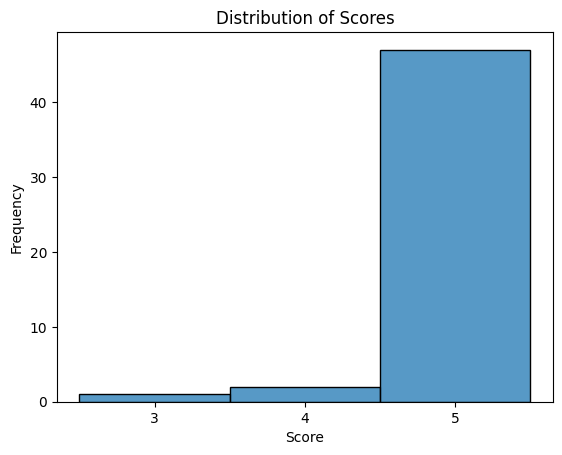

In [ ]:
# Print avg score.
with open(FINAL_OUTPUT_JSON, 'r') as f:
    data = json.load(f)
scores = [dic['score'] for dic in data]
print("Avg score:", sum(scores)/len(scores))

plt.figure()
sns.histplot(scores, discrete=True)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xticks(list(set(scores)))
plt.show()
plt.close()

We've performed different runs of evaluation with deepseek and we've observed that most of the answers get always grade 5.

### Cosine similarity between embeddings

In [ ]:
# Load encoder.
model_id = "sentence-transformers/all-MiniLM-L6-v2"
encoder = SentenceTransformer(model_id)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Avg cosine similarity: 0.750858588218689


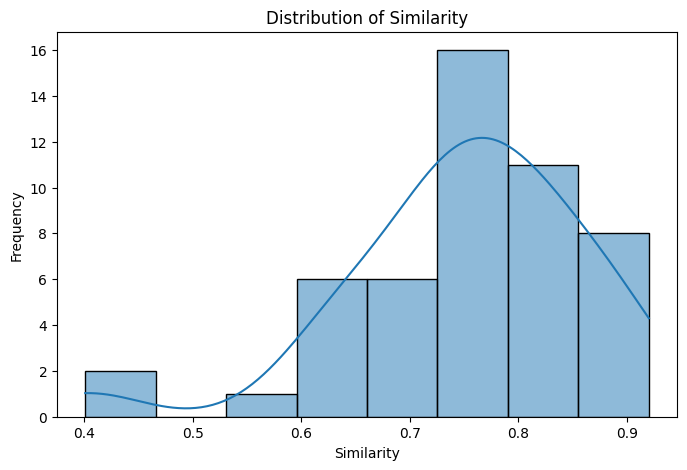

The least similar sentences
Cosine similarity: 0.40093002
Gold answer: It failed because it relied on the "Closed World Assumption," meaning it could not handle undefined objects or unmodeled environmental changes. Furthermore, mathematically describing every action's effect (the Frame Problem) was impossible, and the serial planning cycle was too slow for real-time reactions.
RAG answer: The classic Hierarchical Paradigm (Sense-Plan-Act) ultimately failed to handle real-world robotic applications effectively because of the **Closed World Assumption**, which assumes the internal model is perfect and contains all relevant information. This approach cannot handle new, undefined objects or dynamic changes in the environment, making it unsuitable for real-world scenarios where the world is constantly changing and unpredictable.<|im_end|>


In [ ]:
# Compute cosine similarity for each pair of answer.
gold_answ = [dic['answer'] for dic in data]
rag_answ  = [dic['ragAnswer'] for dic in data]

cos_sim = []
for ga, ra in zip(gold_answ, rag_answ):
    embd = encoder.encode([ga, ra])
    sim = np.dot(embd[0], embd[1]) / (np.linalg.norm(embd[0]) * np.linalg.norm(embd[1]))
    cos_sim.append(sim)

print("Avg cosine similarity:", sum(cos_sim)/len(cos_sim))

plt.figure(figsize=(8, 5))
sns.histplot(cos_sim, kde=True)
plt.title('Distribution of Similarity')
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.show()
plt.close()

# Print the least similar sentences.
m = np.argmin(cos_sim)
print("The least similar sentences")
print("Cosine similarity:", cos_sim[m])
print("Gold answer:", gold_answ[m])
print("RAG answer:", rag_answ[m])

Only 5 pairs have a similarity below 0.65, so this would suggest that the majority of the pairs have a similar semantic meaning. However it is hard to interpret the values that we get. In the following block, just for a comparison we compute the similarity between random pairs: for each gold answer we choose a random rag answer. The output similarities should be low.

Avg cosine similarity: 0.22982323557138443


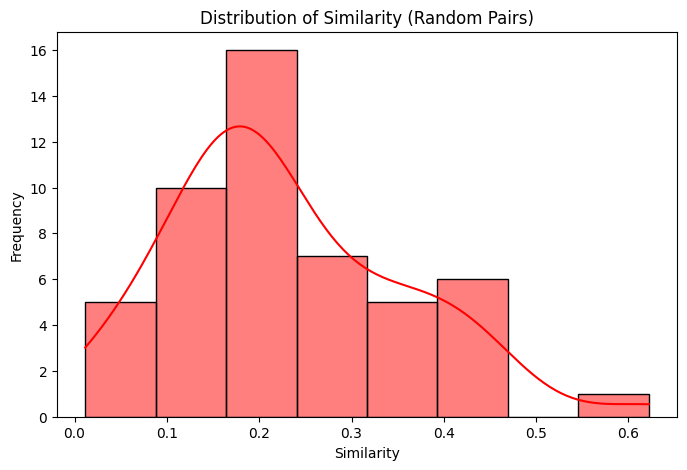

In [ ]:
# Cosine similarity between random pairs.
cos_sim = []
for ga in gold_answ:
    rnd = random.randint(0, len(rag_answ) - 1)
    ra = rag_answ[rnd]
    embd = encoder.encode([ga, ra])
    sim = np.dot(embd[0], embd[1]) / (np.linalg.norm(embd[0]) * np.linalg.norm(embd[1]))
    cos_sim.append(sim)

print("Avg cosine similarity:", sum(cos_sim)/len(cos_sim))

plt.figure(figsize=(8, 5))
sns.histplot(cos_sim, kde=True, color='red')
plt.title('Distribution of Similarity (Random Pairs)')
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.show()
plt.close()

### BERTScore

Small recap of how it works.

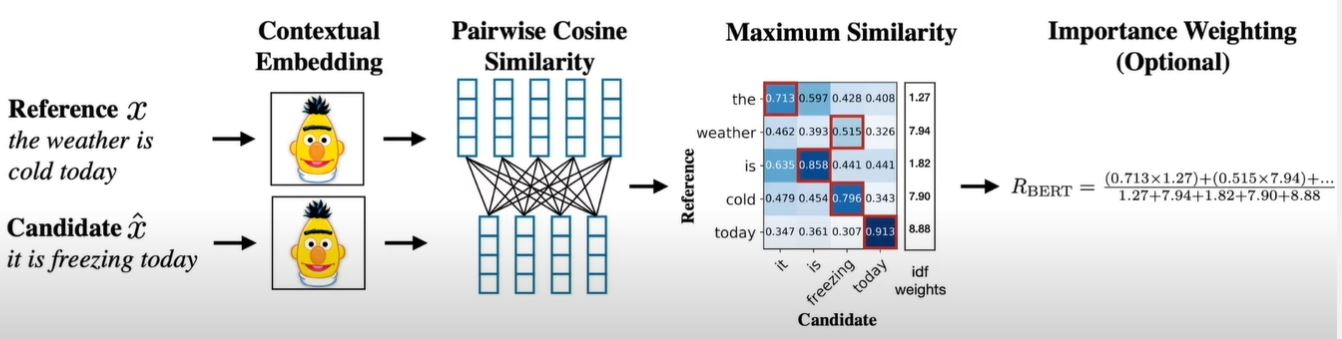
1. **Token Representation**: BERTScore uses pre-trained BERT embeddings to represent tokens (words or subwords) in the text. These embeddings capture the semantic meaning of the tokens in their context.

2. **Cosine Similarity**: After obtaining the embeddings, BERTScore calculates the cosine similarity between the embeddings of the tokens in the generated text and the reference text. This gives a measure of how semantically similar the generated text is to the reference text.

3. **Precision, Recall, and F1 Score**: Each token in the reference sentence is matched to the most similar token in the generated sentence, and vice versa. This process is used to calculate the precision, recall, and F1 score, which are measures of the quality of the generated text.

4. **Importance Weighting** (Optional): This is an optional step in the BERTScore architecture. It assigns different weights to different tokens based on their importance. Tokens that are more likely to be important in the context of the text receive higher weights.

In [ ]:
# Compute bert-score.
P, R, F1 = bscore(gold_answ, rag_answ, lang="en", verbose=True)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.95 seconds, 52.66 sentences/sec


Avg F1: 0.891


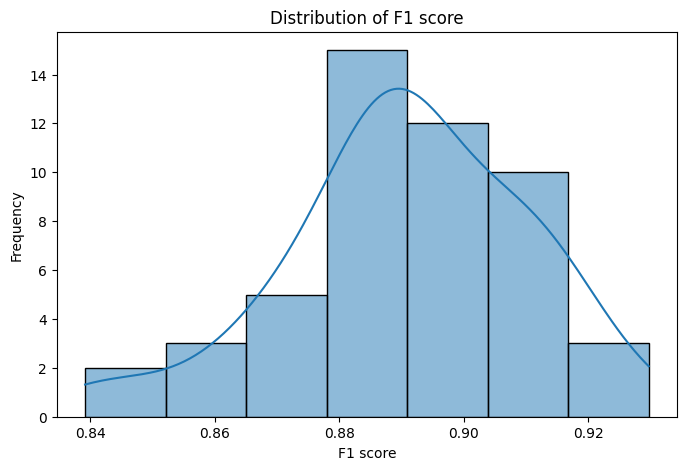

The least similar sentences
Cosine similarity: 0.839206337928772
Gold answer: It extracts Features from raw numerical data, combines features to identify Objects, and finally reasons about object relationships to extract high-level Semantics and Context.
RAG answer: The hierarchical steps in the robot perception pipeline are as follows:

1. **Raw Data**: Collecting sensor inputs (e.g., pixel arrays, range readings).
2. **Features**: Extracting patterns from raw data (e.g., lines, corners, colors).
3. **Objects**: Identifying entities from features (e.g., recognizing a door or a human).
4. **Semantics and Context**: Reasoning about object relationships and understanding the situation (e.g., a door connects two rooms).
5. **Sensor Fusion**: Combining data from multiple sensors to create a comprehensive world model.<|im_end|>


In [ ]:
# Avg F1 score.
print(f"Avg F1: {(sum(F1)/len(F1)).item():.3f}")

# Plot F1 score distribution.
plt.figure(figsize=(8, 5))
sns.histplot(F1, kde=True)
plt.title('Distribution of F1 score')
plt.xlabel('F1 score')
plt.ylabel('Frequency')
plt.show()
plt.close()

# Print the least similar sentences.
m = np.argmin(F1)
print("The least similar sentences")
print("Cosine similarity:", F1[m].item())
print("Gold answer:", gold_answ[m])
print("RAG answer:", rag_answ[m])

Also in this case it's not simple to interpret the values. Just for a comparision, we compute the F1 score for random pairs. We expect to see low values.

In [ ]:
# Compute bert-score for random pairs.
rnd = [rag_answ[random.randint(0, len(rag_answ) - 1)] for _ in range(len(rag_answ))]
P, R, F1 = bscore(gold_answ, rnd, lang="en", verbose=True)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.84 seconds, 59.28 sentences/sec


Avg F1: 0.831


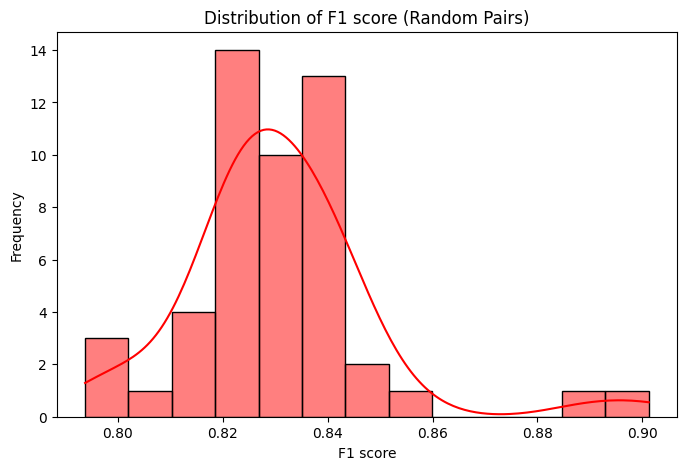

In [ ]:
# Avg F1 score.
print(f"Avg F1: {(sum(F1)/len(F1)).item():.3f}")

# Plot F1 score distribution.
plt.figure(figsize=(8, 5))
sns.histplot(F1, kde=True, color='red')
plt.title('Distribution of F1 score (Random Pairs)')
plt.xlabel('F1 score')
plt.ylabel('Frequency')
plt.show()
plt.close()

In this case we observe that we get lower values but they're still pretty high!